# Application of WAVEGUISE to a AMTM video sequence of brithness measurements over Río Grande, Argentina
This script is to show in detail how WAVEGUISE is applied to a complex 3-D data set and how it retrieves wave packets.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parents[1] / "scripts"))
sys.path.append(str(Path.cwd().parents[2] / "juwavelet"))
from juwavelet import parallel
import waveguise_3d as three
import plot_tools as pt

import numpy as np
import xarray as xr
import time
import matplotlib.pyplot as plt
import copy

from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.colors as mcolors

import pylops

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
data_path = '/project/meteo/work/Robert.Reichert/data/AMTM/Rio_Grande/2018/201805/AMTM_BI_20180516-2137.nc'
ds = xr.open_dataset(data_path)

## Data Preprocessing
Before the observational data set is ready for the wavelet transform, we must take care of the data boundaries. These non-periodic boundaries can create strong frequency responses and later on fuck up the wavefield segmentation. The first step is to use a least square polynomial 3D fit of max_order and subtract the result. In a second step, the zeroth and first Fourier components are also subtracted. In a final step, a Tukey window is applied to smoothly enforce the signal to zero at the edges. 

In [3]:
BI = ds['band intensity'].isel(time=slice(100,255),x=slice(3,-40),y=slice(35,-42))
BI_high = BI.values
BI_high = np.flip(BI_high,axis=0)
BI_high, _ = three.BG_removal(BI_high,max_order=1,fourier_radius=1)

In [4]:
dx, dy, dt = 625, 625, 35
nx, ny, nt = BI['y'].size, BI['x'].size, BI['time'].size
print(nx, ny, nt)

nmask = (ny, nx, nt)
ntap = (20,20,5)
tap3d = pylops.utils.tapers.tapernd(nmask, ntap, "hanning")
new_data = BI_high*tap3d

243 213 155


## Wavelet Transform
When we do the juwavelet transform we need to choose the number of scales $js$, azimuth orientations $jt$, and zenith orientations $jp$. The smallest scales is defined as $s_0=4*\delta x$. In addition, I adjust the aspect paramter $a$ which effectively adjusts the smapling of detected phase speeds. The number of scales is taken to depend on the data dimensions and since the first Fourier component is already subtracted, we focus here on wavelengths shorter than that. For more details on juwavelet, please have a look at Ungermann and Reichert (2025).

In [5]:
a  = 2*dx/dt
s0 = 4 
s1 = 0.5 * min([nx,ny,nt])
dj = 1/4
js = int(1/dj*np.log2(s1/s0))
jt=10
jp=15
print(a, nx, ny, nt, js, jt, jp, js*jt*jp)

35.714285714285715 243 213 155 17 10 15 2550


In [6]:
noise_floor = 80# 0.1*np.std(new_data)
print('Noise floor:', noise_floor)
cwt_result = parallel.decompose3d_parallel(np.transpose(new_data,(1,0,2)), dx, dy, dt, s0*min([dx,dy,dt*a]), dj, js, jt, jp, aspect=a,
    nxpad=None, nypad=None, nzpad=None, opts={'param': 2*np.pi},mode="scaled", dtype=np.complex64, filt={'min_coefficient': noise_floor})

Noise floor: 80
pr/tr 4 4


  0%|          | 0/17 [00:00<?, ?it/s]/home/r/Robert.Reichert/juwavelet/juwavelet/parallel.py:331: RuntimeWarning: divide by zero encountered in divide
  wxs = periods[:, np.newaxis, np.newaxis] / (
/home/r/Robert.Reichert/juwavelet/juwavelet/parallel.py:331: RuntimeWarning: divide by zero encountered in divide
  wxs = periods[:, np.newaxis, np.newaxis] / (
/home/r/Robert.Reichert/juwavelet/juwavelet/parallel.py:331: RuntimeWarning: divide by zero encountered in divide
  wxs = periods[:, np.newaxis, np.newaxis] / (
/home/r/Robert.Reichert/juwavelet/juwavelet/parallel.py:331: RuntimeWarning: divide by zero encountered in divide
  wxs = periods[:, np.newaxis, np.newaxis] / (
/home/r/Robert.Reichert/juwavelet/juwavelet/parallel.py:331: RuntimeWarning: divide by zero encountered in divide
  wxs = periods[:, np.newaxis, np.newaxis] / (
 12%|█▏        | 2/17 [10:50<1:07:46, 271.10s/it]/home/r/Robert.Reichert/juwavelet/juwavelet/parallel.py:331: RuntimeWarning: divide by zero encountered in d

In [7]:
print(f"The data resolution is {dx*1e-3:.1f} km and the smallest wavelength you analyze is {s0*dx*1e-3:.1f} km.")
print(f"The data resolution is {dt:.0f} s and the shortest period you analyze is {s0*dt:.0f} s.")
print(f"The spatial domain is at least {min([nx,ny])*dx*1e-3:.0f} km and the largest wavelength you analyze is {s1*dx*1e-3:.0f} km.")
print(f"The time domain is {nt*dt/60:.0f} min and the longest period you analyze is {s1*dt/60:.0f} min.")

The data resolution is 0.6 km and the smallest wavelength you analyze is 2.5 km.
The data resolution is 35 s and the shortest period you analyze is 140 s.
The spatial domain is at least 133 km and the largest wavelength you analyze is 47 km.
The time domain is 88 min and the longest period you analyze is 44 min.


## Denoising in 6D i.e. WAS Reduction
The WAS of a 3-D data set is 6-D and in this case simply too large to be processed. In order to handle the WAS, I reduce it's dimensions by computing the 95th percentile along the spatial dimensions. The resuting object is 4-D and has dimensions of scale, azimuth angle, zenith angle, and time, i.e. $|W|(s,\vartheta,\varphi,t)$. After that step no additional denoising is needed.

In [7]:
WAS = three.reduce_WAS_624D(cwt_result['decomposition'],percentile=95)

## Segmentation
In the following step, we apply the watershed segmentation algorithm to the reduced WAS. A crucial parameter is the prominence, which defines the height of a peak in the WAS comapred to its neighborhood. A suggestion for the prominence parameter would be the noise level of the underlying data. Depending on the prominence parameter we will find more or less wave packets.

In [8]:
seg_v1    = three.wavefield_segmentation_3d(WAS, noise_floor, (1,2))
print('Identified', np.max(seg_v1), 'initial wave packets!')
WP_labels = np.arange(1,np.max(seg_v1)+1)

Identified 8 initial wave packets!


<xarray.DataArray 'time' ()> Size: 8B
array('2018-05-16T23:32:40.002000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2018-05-16T23:32:40.002000


Text(0, 0.5, 'scale')

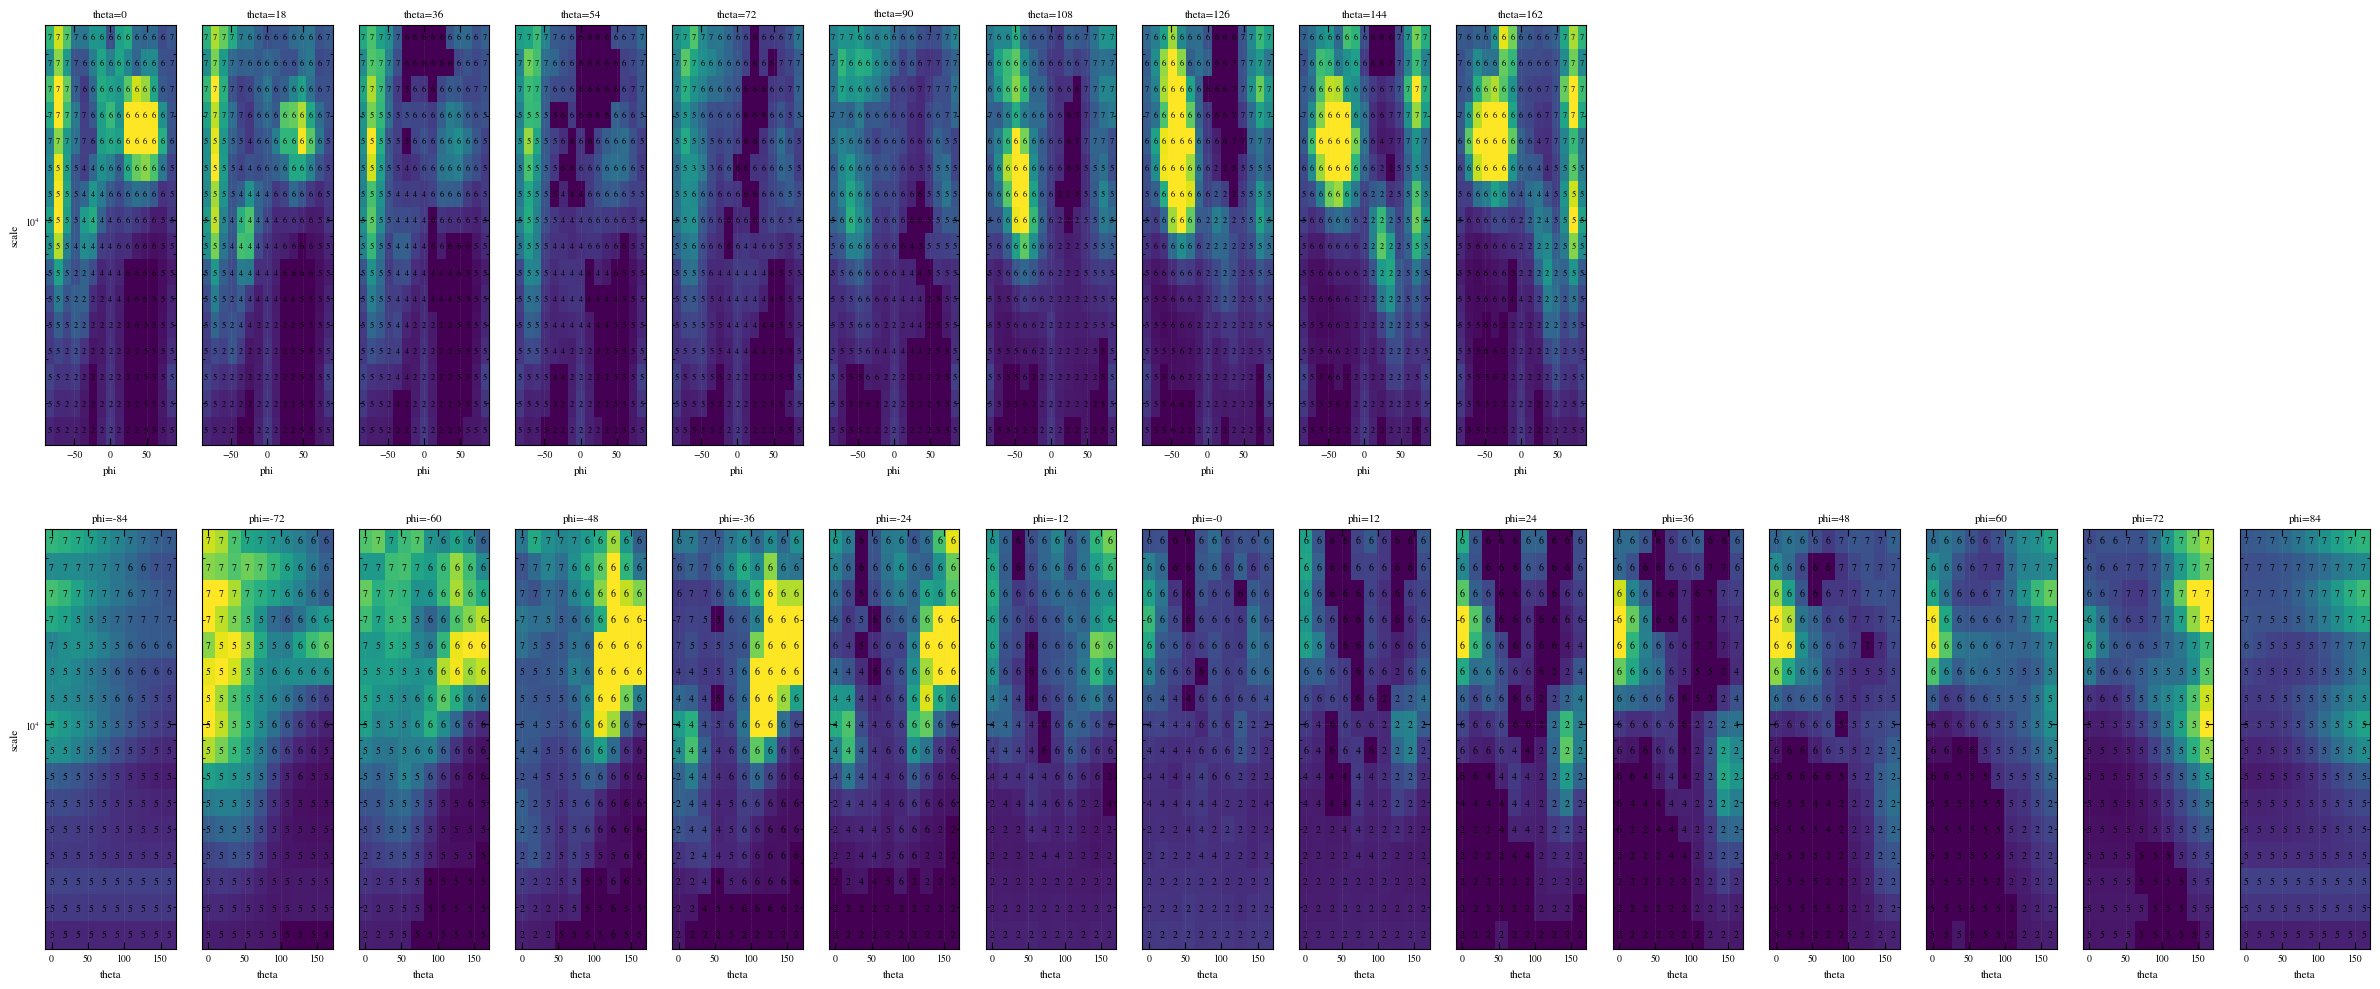

In [13]:
time_index=100
print(BI['time'].isel(time=time_index))

spec_lev = np.linspace(0, 300, 31)
gskw = {
    "hspace": 0.2, "wspace": 0.2,
    "width_ratios": [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    "height_ratios": [1, 1]
}

x=np.rad2deg(cwt_result['phi'])
y=cwt_result['scale']

fig, ax = plt.subplots(2, 15, figsize=(15*2, 6*2), gridspec_kw=gskw, sharey=True)
ax[0,10].axis('off')
ax[0,11].axis('off')
ax[0,12].axis('off')
ax[0,13].axis('off')
ax[0,14].axis('off')

# --- top row ---
for i in range(len(cwt_result['theta'])):
    pcm = ax[0, i].pcolormesh(x,y,WAS[:, i, :, time_index],vmin=spec_lev.min(), vmax=spec_lev.max(), shading="auto")
    ax[0, i].set_title(f"theta={np.rad2deg(cwt_result['theta'][i]):.0f}")
    ax[0, i].set_yscale('log')
    ax[0, i].set_xlabel('phi')

    for k,xi in enumerate(x):
        for l,yi in enumerate(y):
            if seg_v1[l,i,k, time_index]==0:
                continue
            ax[0,i].text(xi,yi,str(seg_v1[l,i,k,time_index]),horizontalalignment='center',verticalalignment='center',fontsize=6)

ax[0,0].set_ylabel('scale')


x=np.rad2deg(cwt_result['theta'])

# --- bottom row ---
for i in range(len(cwt_result['phi'])):
    pcm = ax[1, i].pcolormesh(x,y,WAS[:, :, i, time_index], vmin=spec_lev.min(), vmax=spec_lev.max(),shading="auto")
    ax[1, i].set_title(f"phi={np.rad2deg(cwt_result['phi'][i]):.0f}")
    ax[1, i].set_yscale('log')
    ax[1, i].set_xlabel('theta')

    for k,xi in enumerate(x):
        for l,yi in enumerate(y):
            if seg_v1[l,k,i, time_index]==0:
                continue
            ax[1,i].text(xi,yi,str(seg_v1[l,k,i, time_index]),horizontalalignment='center',verticalalignment='center',fontsize=7)

ax[1,0].set_ylabel('scale')

#plt.savefig('ANGWIN_3d_spectrum.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

## Reconstruction
Every wave packet is reconstructed separately.

In [ ]:
CWT_filt = copy.deepcopy(cwt_result)

# 1) Build your condition on B 
mask = (seg_v1 == 7) | (seg_v1 == 8)# | (seg == 12) | (seg == 11) | (seg == 13)

# 2) Get only the indices to touch
idxs = np.argwhere(~mask)  # shape (n_true, 3)

# 3) Zero each selected 3D block in place (no extra allocations)
for i, j, k, l in idxs:
    if CWT_filt['decomposition'][i][j][k] is None:
        continue
    else:
        CWT_filt['decomposition'][i][j][k][:,:,l].fill(0)     # fastest; modifies the existing array

recon = parallel.reconstruct3d_parallel(CWT_filt)

 82%|████████▏ | 14/17 [03:55<00:54, 18.15s/it]

In [ ]:
da_WP = xr.DataArray(
    recon,
    dims=("x", "y", "time"),
    coords={"x": BI['y'].values, "y": BI['x'].values, "time": BI.time},
    name="BI_recon",
)
da_WP = da_WP.astype("float32")
encoding = {"BI_recon": {"zlib": True, "complevel": 5}}
da_WP.to_netcdf('../data/AMTM_recon_big.nc', encoding=encoding)

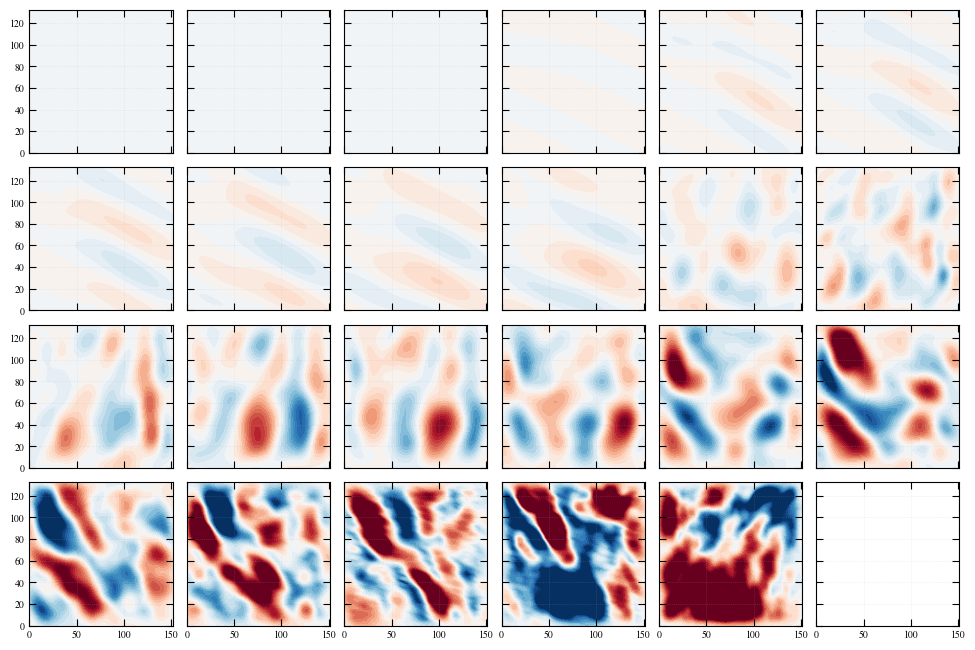

In [26]:
# WP 1
BI_lev = np.linspace(-1000,1000,31)

rows, columns = 4, 6#pt.define_figgrid(155/(4*6))
step=7#int(155/22)
gskw = {"hspace": 0.1, "wspace": 0.1, "width_ratios": [1]*columns, "height_ratios": [1]*rows}

fig, ax = plt.subplots(rows,columns,figsize=(2*columns,2*rows), gridspec_kw=gskw, sharex=True, sharey=True)
for i in range(rows):
    for j in range(columns):
        idx=i*columns+j
        if step*idx > 155:
            continue
        ax[i][j].contourf(np.linspace(0,(nx-1)*dx,nx)*1e-3,np.linspace(0,(ny-1)*dy,ny)*1e-3,recon[:,:,step*idx].T,levels=BI_lev,extend='both',cmap='RdBu_r')

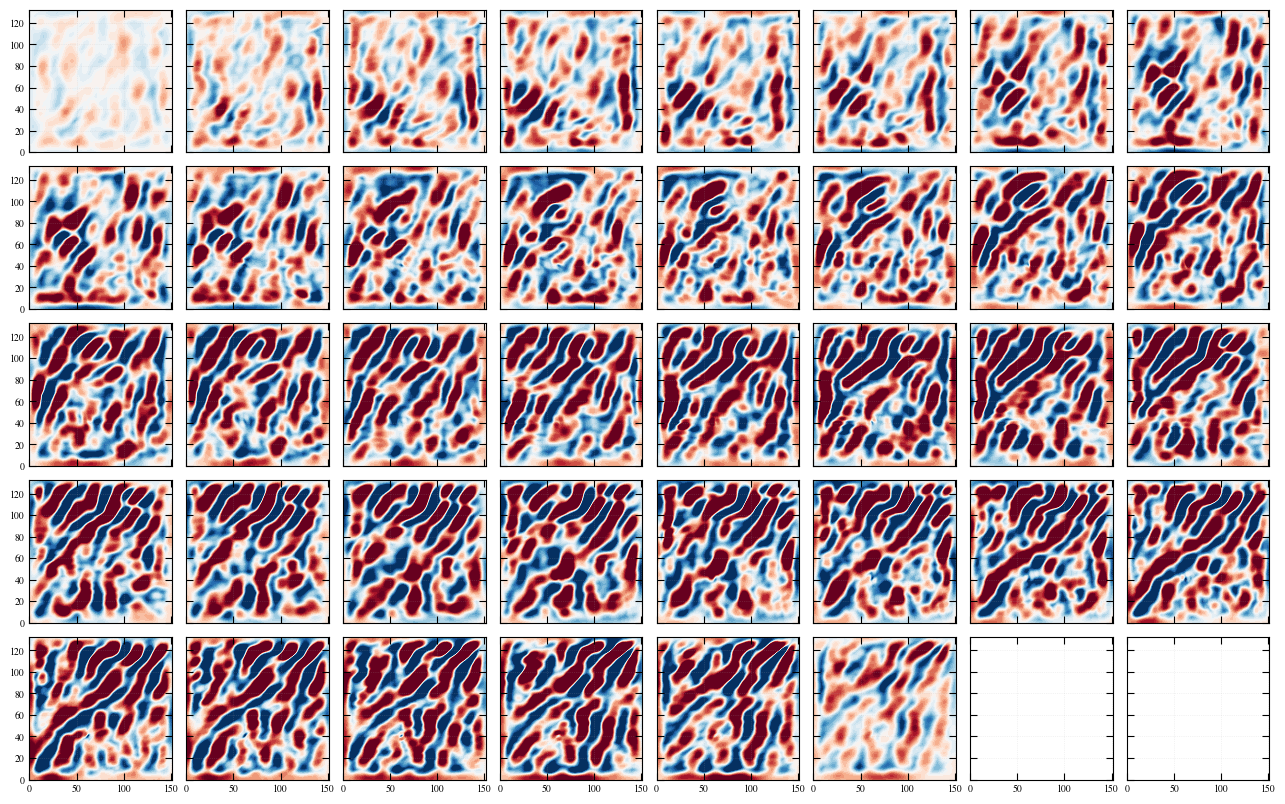

In [39]:
# Cluster 6
BI_lev = np.linspace(-1000,1000,31)

rows, columns = 5, 8#pt.define_figgrid(38)
gskw = {"hspace": 0.1, "wspace": 0.1, "width_ratios": [1]*columns, "height_ratios": [1]*rows}

fig, ax = plt.subplots(rows,columns,figsize=(2*columns,2*rows), gridspec_kw=gskw, sharex=True, sharey=True)
for i in range(rows):
    for j in range(columns):
        idx=i*columns+j
        if 4*idx > 150:
            continue
        ax[i][j].contourf(np.linspace(0,(nx-1)*dx,nx)*1e-3,np.linspace(0,(ny-1)*dy,ny)*1e-3,recon[:,:,4*idx].T,levels=BI_lev,extend='both',cmap='RdBu_r')

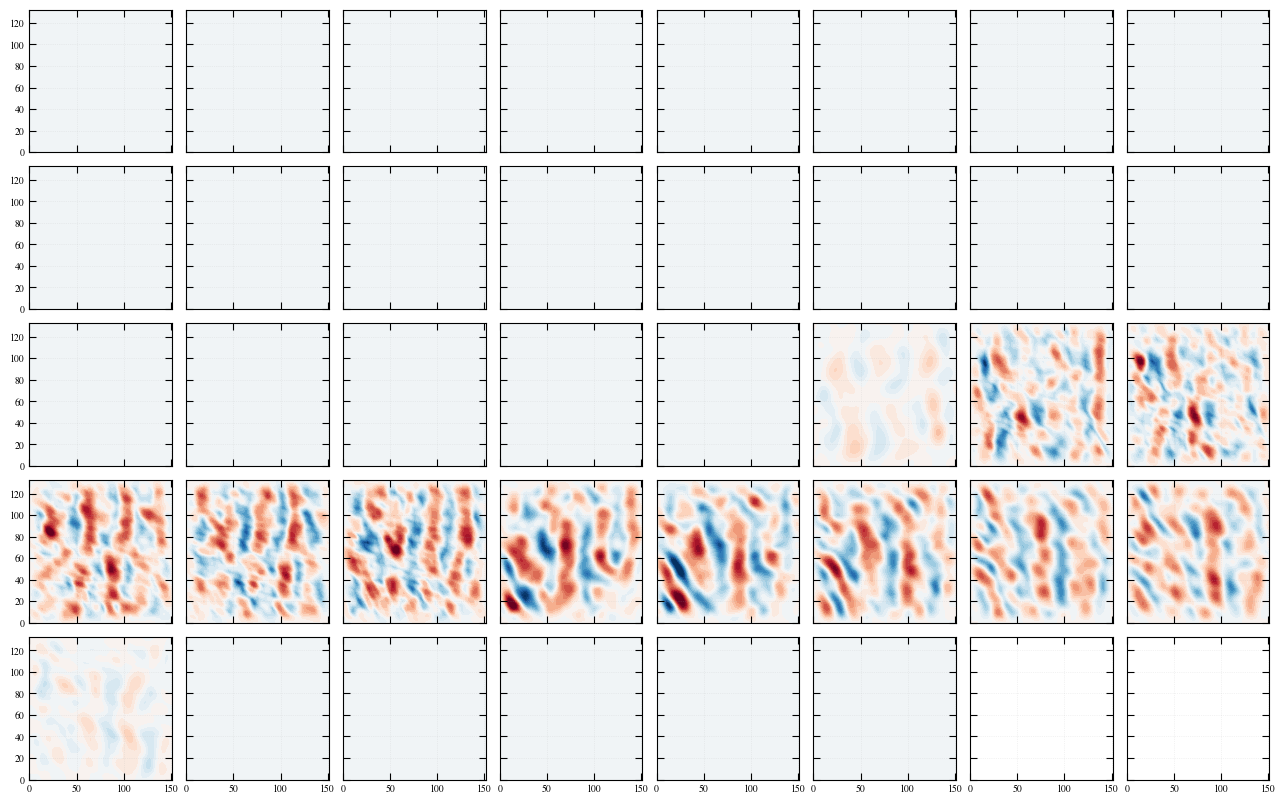

In [36]:
# Cluster 5
BI_lev = np.linspace(-1000,1000,31)

rows, columns = 5, 8#pt.define_figgrid(38)
gskw = {"hspace": 0.1, "wspace": 0.1, "width_ratios": [1]*columns, "height_ratios": [1]*rows}

fig, ax = plt.subplots(rows,columns,figsize=(2*columns,2*rows), gridspec_kw=gskw, sharex=True, sharey=True)
for i in range(rows):
    for j in range(columns):
        idx=i*columns+j
        if 4*idx > 150:
            continue
        ax[i][j].contourf(np.linspace(0,(nx-1)*dx,nx)*1e-3,np.linspace(0,(ny-1)*dy,ny)*1e-3,recon[:,:,4*idx].T,levels=BI_lev,extend='both',cmap='RdBu_r')

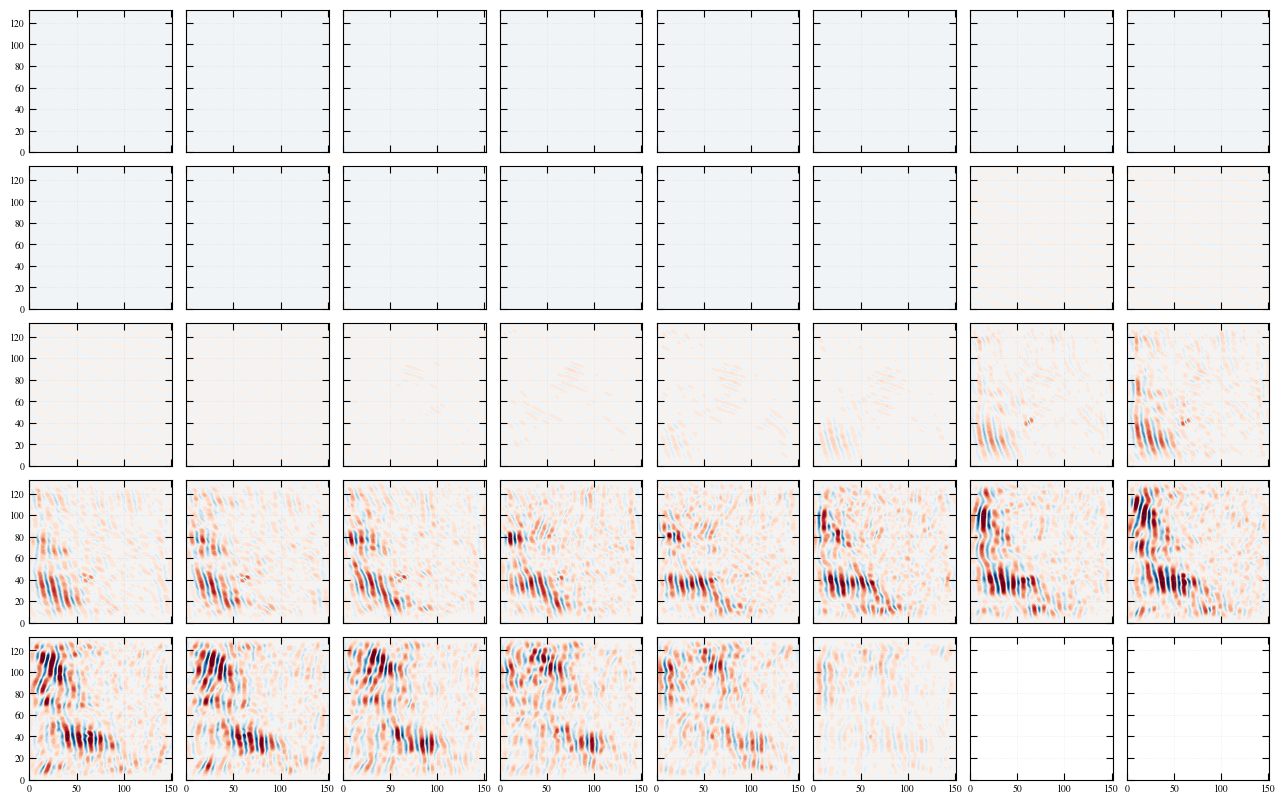

In [33]:
# Cluster 4
BI_lev = np.linspace(-1000,1000,31)

rows, columns = 5, 8#pt.define_figgrid(38)
gskw = {"hspace": 0.1, "wspace": 0.1, "width_ratios": [1]*columns, "height_ratios": [1]*rows}

fig, ax = plt.subplots(rows,columns,figsize=(2*columns,2*rows), gridspec_kw=gskw, sharex=True, sharey=True)
for i in range(rows):
    for j in range(columns):
        idx=i*columns+j
        if 4*idx > 150:
            continue
        ax[i][j].contourf(np.linspace(0,(nx-1)*dx,nx)*1e-3,np.linspace(0,(ny-1)*dy,ny)*1e-3,recon[:,:,4*idx].T,levels=BI_lev,extend='both',cmap='RdBu_r')

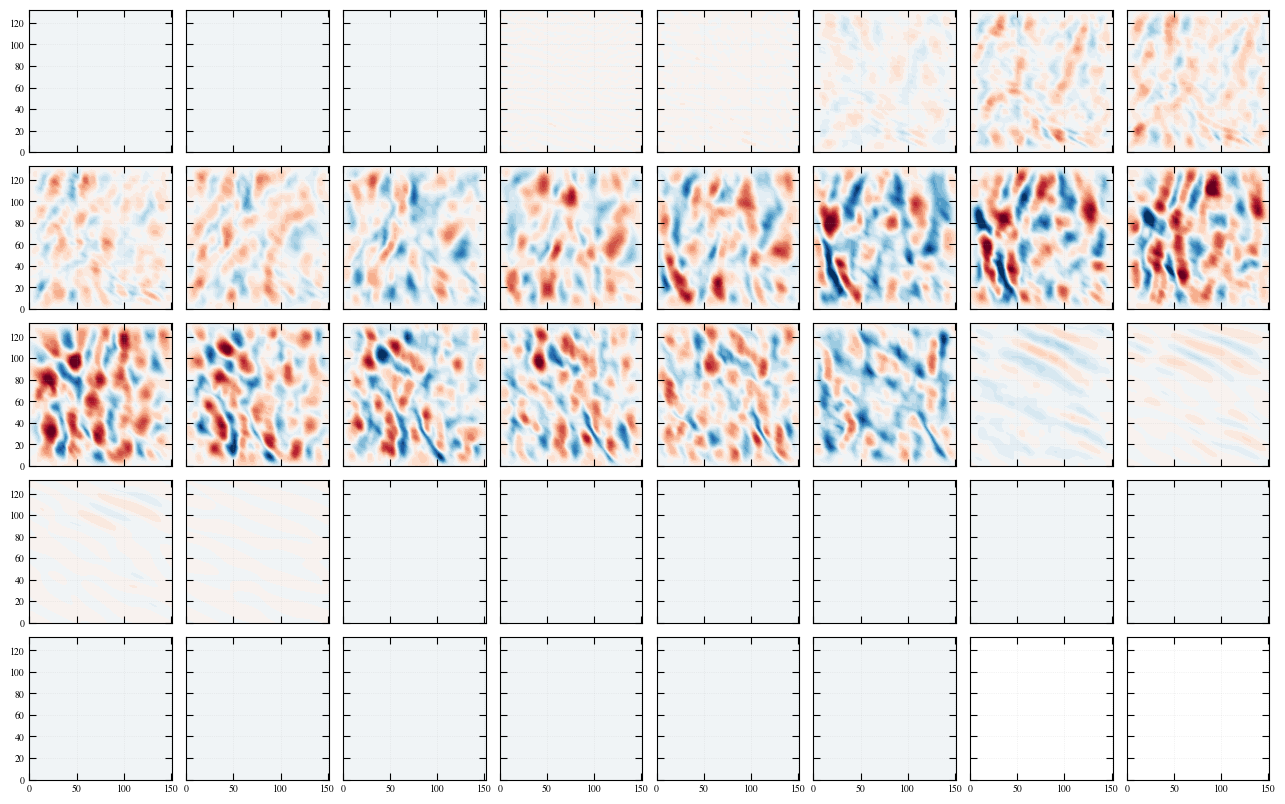

In [30]:
# Cluster 3
BI_lev = np.linspace(-1000,1000,31)

rows, columns = 5, 8#pt.define_figgrid(38)
gskw = {"hspace": 0.1, "wspace": 0.1, "width_ratios": [1]*columns, "height_ratios": [1]*rows}

fig, ax = plt.subplots(rows,columns,figsize=(2*columns,2*rows), gridspec_kw=gskw, sharex=True, sharey=True)
for i in range(rows):
    for j in range(columns):
        idx=i*columns+j
        if 4*idx > 150:
            continue
        ax[i][j].contourf(np.linspace(0,(nx-1)*dx,nx)*1e-3,np.linspace(0,(ny-1)*dy,ny)*1e-3,recon[:,:,4*idx].T,levels=BI_lev,extend='both',cmap='RdBu_r')

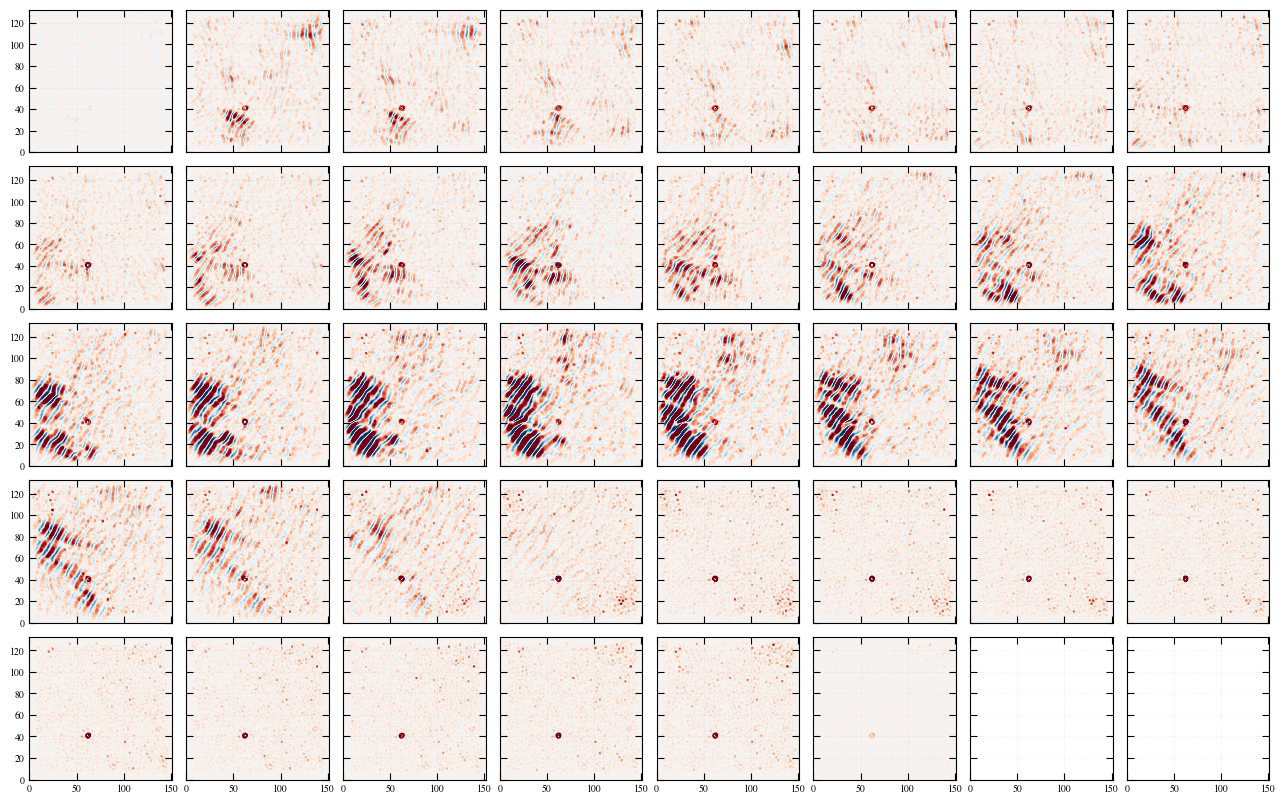

In [27]:
# Cluster 2
BI_lev = np.linspace(-1000,1000,31)

rows, columns = 5, 8#pt.define_figgrid(38)
gskw = {"hspace": 0.1, "wspace": 0.1, "width_ratios": [1]*columns, "height_ratios": [1]*rows}

fig, ax = plt.subplots(rows,columns,figsize=(2*columns,2*rows), gridspec_kw=gskw, sharex=True, sharey=True)
for i in range(rows):
    for j in range(columns):
        idx=i*columns+j
        if 4*idx > 150:
            continue
        ax[i][j].contourf(np.linspace(0,(nx-1)*dx,nx)*1e-3,np.linspace(0,(ny-1)*dy,ny)*1e-3,recon[:,:,4*idx].T,levels=BI_lev,extend='both',cmap='RdBu_r')

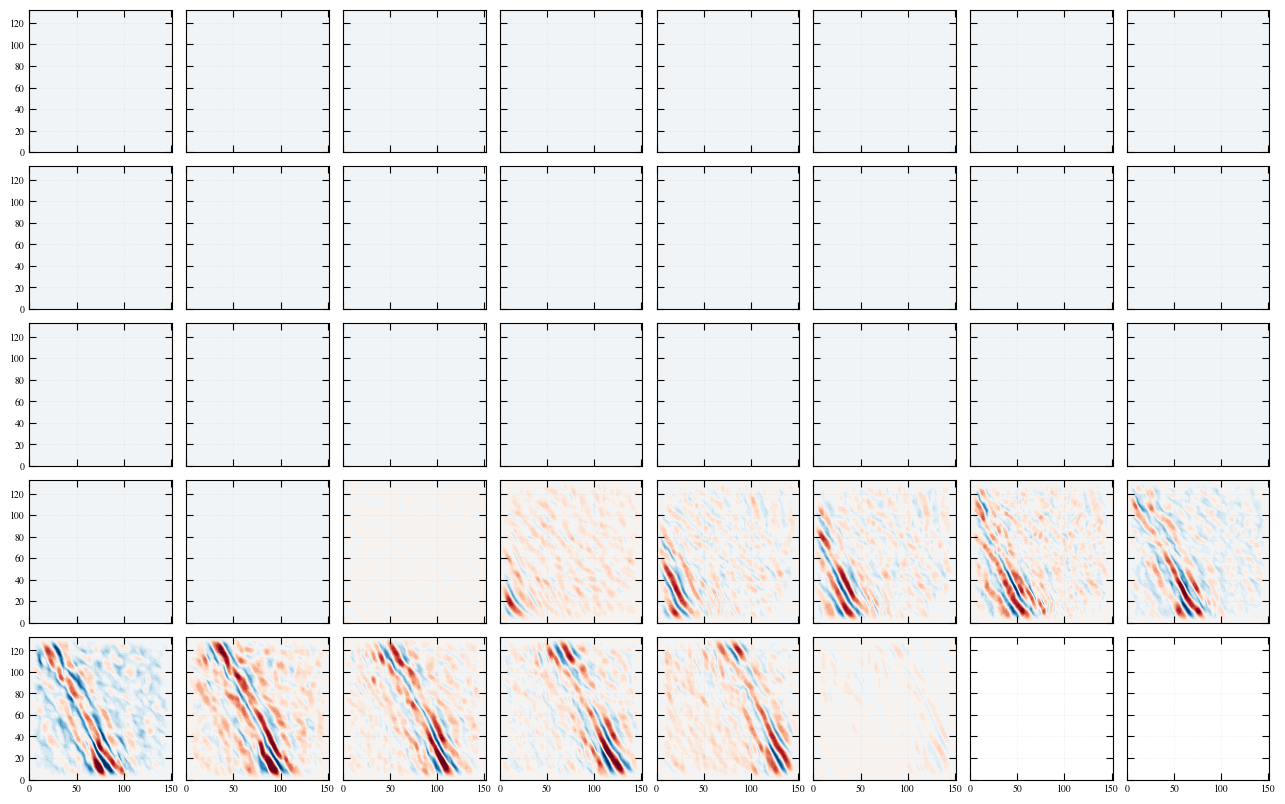

In [24]:
# Cluster 1
BI_lev = np.linspace(-1000,1000,31)

rows, columns = 5, 8#pt.define_figgrid(38)
gskw = {"hspace": 0.1, "wspace": 0.1, "width_ratios": [1]*columns, "height_ratios": [1]*rows}

fig, ax = plt.subplots(rows,columns,figsize=(2*columns,2*rows), gridspec_kw=gskw, sharex=True, sharey=True)
for i in range(rows):
    for j in range(columns):
        idx=i*columns+j
        if 4*idx > 150:
            continue
        ax[i][j].contourf(np.linspace(0,(nx-1)*dx,nx)*1e-3,np.linspace(0,(ny-1)*dy,ny)*1e-3,recon[:,:,4*idx].T,levels=BI_lev,extend='both',cmap='RdBu_r')

In [43]:
da_WP = xr.DataArray(
    recon,
    dims=("x", "y", "time"),
    coords={"x": BI['y'].values, "y": BI['x'].values, "time": BI.time},
    name="BI_recon",
)
da_WP = da_WP.astype("float32")
encoding = {"BI_recon": {"zlib": True, "complevel": 5}}
da_WP7.to_netcdf('../data/AMTM_recon_WP1.nc', encoding=encoding)

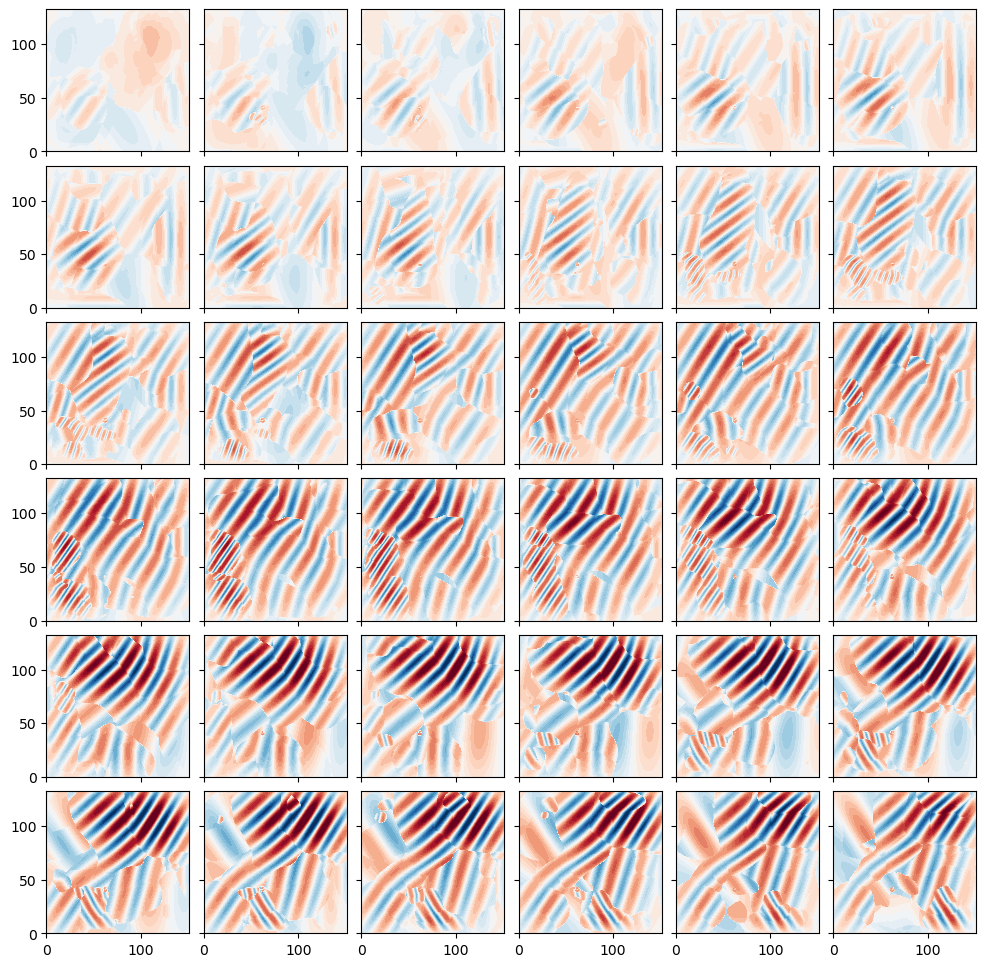

In [30]:
# Reconstruction of dominant Waves
BI_lev = np.linspace(-1000,1000,31)

rows, columns = pc.define_grid(32)
gskw = {"hspace": 0.1, "wspace": 0.1, "width_ratios": [1]*columns, "height_ratios": [1]*rows}

fig, ax = plt.subplots(rows,columns,figsize=(2*rows,2*columns), gridspec_kw=gskw, sharex=True, sharey=True)
for i in range(columns):
    for j in range(rows):
        idx=i*columns+j
        if 4*idx > 150:
            continue
        ax[i][j].contourf(np.linspace(0,(nx-1)*dx,nx)*1e-3,np.linspace(0,(ny-1)*dy,ny)*1e-3,recon_domi[:,:,4*idx].T,levels=BI_lev,extend='both',cmap='RdBu_r')

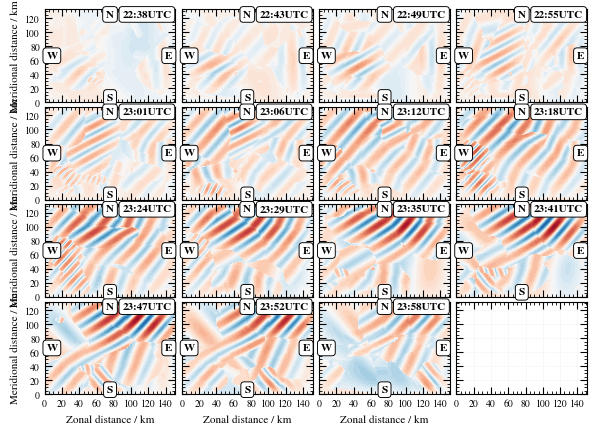

In [44]:
BI_lev = np.linspace(-1500,1500,51)
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3

gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1, 1, 1, 1], "height_ratios": [1, 1, 1, 1]}

time_indexes=np.linspace(5,155,16)
fig, ax=plt.subplots(4,4, figsize=(7,5), gridspec_kw=gskw,sharex=True, sharey=True)

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        if int(time_indexes[i*ax.shape[1]+j]) < 150:
            ax[i,j].contourf(x,y,recon_domi[:,:,int(time_indexes[i*ax.shape[1]+j])].T,levels=BI_lev,extend='both',cmap='RdBu_r')

yl = ['Meridional distance / km','','','','Meridional distance / km','','','',
     'Meridional distance / km','','','','Meridional distance / km','','','']
xl = ['','','','','','','','','','','','',
      'Zonal distance / km','Zonal distance / km','Zonal distance / km','Zonal distance / km']

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        if int(time_indexes[i*ax.shape[1]+j]) < 150:
            ax[i,j].set_ylabel(yl[i*ax.shape[1]+j])
            ax[i,j].set_xlabel(xl[i*ax.shape[1]+j])
            ax[i,j].yaxis.set_major_locator(MultipleLocator(20))
            ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())
            ax[i,j].xaxis.set_major_locator(MultipleLocator(20))
            ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())
            #ax[i,j].tick_params(which='both', labelbottom=True, labeltop=False)
            ax[i,j].grid()
            ax[i,j].text(0.5, 0.945, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                            weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
            ax[i,j].text(0.5, 0.05, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                            weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
            ax[i,j].text(0.055, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                            weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
            ax[i,j].text(0.95, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                            weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
            ax[i,j].text(0.97, 0.945, str(BI['time'].isel(time=int(time_indexes[i*ax.shape[1]+j])).values)[11:16]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[i,j].transAxes, 
                                            weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

#ax[1,0].tick_params(labelbottom=False)
#ax[1,1].tick_params(labelbottom=False)
#ax[1,2].tick_params(labelbottom=False)

plt.savefig('./figures/AMTM_recon_domi.png', dpi=300, bbox_inches="tight", pad_inches=0.03)

In [47]:
da_domi = xr.DataArray(
    recon_domi,
    dims=("x", "y", "time"),
    coords={
        "x": x,   
        "y": y,   
        "time": BI.time
    },
    name="dominant_mode_reconstruction",
)
da_domi = da_domi.astype("float32")
encoding = {
    "dominant_mode_reconstruction": {
        "zlib": True,
        "complevel": 5
    }
}
da_domi.to_netcdf('../data/AMTM_dominant_wave_mode_recon.nc', encoding=encoding)

In [37]:
for s in range(1,np.max(seg_v1)+1):
    mask = (seg_v1 == s)
    idxs = np.argwhere(mask)  
    seg_sum=0
    for i, j, k, l in idxs:
        seg_sum+=result[i,j,k,l]#np.abs(cwt_result['decomposition'][i][j][k])#.fill(0)     # fastest; modifies the existing array
    #print(f"{'Summe':10s}: {seg_sum:.1f}")
    print(f"{'Summe:':<10}{np.log(seg_sum):>10}")

Summe:    15.916263911923465
Summe:    13.857806703011072
Summe:    13.163023717032049
Summe:    14.065499655345791
Summe:    14.15905833766715
Summe:    13.205535374312493
Summe:    14.191289928311257
Summe:    13.95320074351145
Summe:    12.62317302279144
Summe:    12.766441200019752
Summe:    13.675238246558354
Summe:    11.274365213988494
Summe:    13.731787353718984
Summe:    14.081221680092677
Summe:    11.844700747081095
Summe:    10.98875664961774
Summe:    13.78119759840611
Summe:    11.044471945664263
Summe:    12.946143054800695
Summe:    12.432440878075075
Summe:    12.361044946820885
Summe:    11.0817928010565
Summe:    12.46102146697665
Summe:    12.511719200619037
Summe:    11.135582117600554
Summe:    13.419090599926019
Summe:    11.90092003390311
Summe:    13.0415720595934
Summe:    11.501716712163248
Summe:    12.139245406556752
Summe:    10.713835283038666
Summe:    11.087023664307333
Summe:    11.242965464981717
Summe:    11.330752298021974
Summe:    13.319847926757

In [22]:
CWT_filt = copy.deepcopy(cwt_result)

# 1) Build your condition on B 
mask = (seg_v1 == 1)# | (seg == 7) | (seg == 12) | (seg == 11) | (seg == 13)

# 2) Get only the indices to touch
idxs = np.argwhere(~mask)  # shape (n_true, 3)

# 3) Zero each selected 3D block in place (no extra allocations)
for i, j, k, l in idxs:
    if CWT_filt['decomposition'][i][j][k] is None:
        continue
    else:
        CWT_filt['decomposition'][i][j][k][:,:,l].fill(0)     # fastest; modifies the existing array

recon = parallel.reconstruct3d_parallel(CWT_filt)

100%|██████████| 16/16 [03:28<00:00, 13.00s/it]


In [23]:
da_WP1 = xr.DataArray(
    recon,
    dims=("x", "y", "time"),
    coords={
        "x": BI['y'].values,   
        "y": BI['x'].values,   
        "time": BI.time
    },
    name="recon_WP1",
)
da_WP1 = da_WP1.astype("float32")
encoding = {
    "recon_WP1": {
        "zlib": True,
        "complevel": 5
    }
}
da_WP1.to_netcdf('../data/AMTM_recon_WP1.nc', encoding=encoding)

In [29]:
# Nur flache Kopie des Dicts
CWT_filt = cwt_result.copy()

# Neue verschachtelte Listenstruktur, aber Inhalte zunächst referenzieren
dec_src = cwt_result['decomposition']
dec_new = [[[cell for cell in row2] for row2 in row1] for row1 in dec_src]

mask = (seg == 2)

# Indizes, die auf 0 gesetzt werden sollen
idxs = np.argwhere(~mask)

# Merken, welche Blöcke bereits kopiert wurden
copied_blocks = set()

for i, j, k, l in idxs:
    block = dec_new[i][j][k]

    if block is None:
        continue

    key = (i, j, k)

    # Nur beim ersten Zugriff auf diesen Block kopieren
    if key not in copied_blocks:
        dec_new[i][j][k] = block.copy()
        copied_blocks.add(key)

    dec_new[i][j][k][:, :, l].fill(0)

CWT_filt['decomposition'] = dec_new

recon = parallel.reconstruct3d_parallel(CWT_filt)

100%|██████████| 16/16 [03:55<00:00, 14.71s/it]


In [68]:
kx_seg, ky_seg, kz_seg = segments2points(WPS,cwt_result['wavelength_x'],cwt_result['wavelength_y'],cwt_result['wavelength_z'],_seg)

/scratch-local/slurm-job-tmp-13578742/ipykernel_949/3787262159.py:20: RuntimeWarning: invalid value encountered in multiply
  kx[idx] = np.sum(kx0 * weights) / wsum


In [69]:
kx_seg

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan])

In [5]:
ds_WP1 = xr.open_dataset('../data/AMTM_recon_WP1.nc')
ds_WP2 = xr.open_dataset('../data/AMTM_recon_WP2.nc')
ds_WP3 = xr.open_dataset('../data/AMTM_recon_WP3.nc')
ds_WP4 = xr.open_dataset('../data/AMTM_recon_WP4.nc')
ds_WP5 = xr.open_dataset('../data/AMTM_recon_WP5.nc')

'\nyl = [\'Meridional distance / km\',\'\',\'\',\'Meridional distance / km\',\'\',\'\']\nxl = [\'\',\'\',\'\',\'Zonal distance / km\',\'Zonal distance / km\',\'Zonal distance / km\']\n\nfor i in range(1,3):\n    for j in range(3):\n        ax[i,j].set_ylabel(yl[3*(i-1)+j])\n        ax[i,j].set_xlabel(xl[3*(i-1)+j])\n        ax[i,j].yaxis.set_major_locator(MultipleLocator(20))\n        ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())\n        ax[i,j].xaxis.set_major_locator(MultipleLocator(20))\n        ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())\n        ax[i,j].tick_params(which=\'both\', labelbottom=True, labeltop=False)\n        ax[i,j].grid()\n        ax[i,j].text(0.5, 0.95, \'N\', verticalalignment=\'center\', horizontalalignment=\'center\', transform=ax[i,j].transAxes, \n                                        weight=\'bold\', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})\n        ax[i,j].text(0.5, 0.05, \'S\', verticalalignment=\'ce

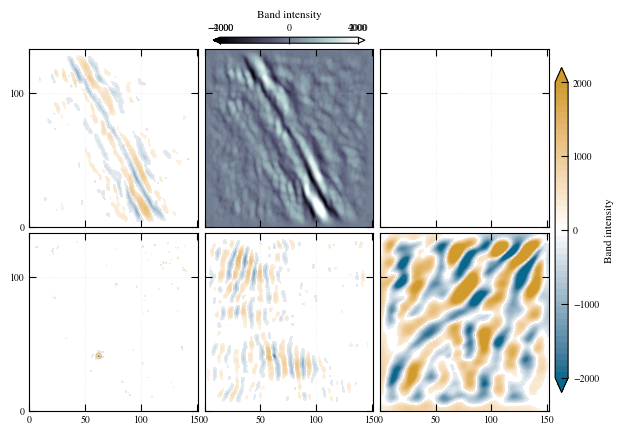

In [17]:
thr = 240
max_abs = 2000
BI_lev0 = np.linspace(-4000,4000,51)
BI_lev0 = np.linspace(-1000,1000,51)
BI_lev = np.linspace(-2000,2000,51)
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1, 1, 1, 0.1], "height_ratios": [0.1, 1, 1]}
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)
royal=get_cmap().reversed()


time_idx=135
fig, ax=plt.subplots(3,4, figsize=(7,5), gridspec_kw=gskw,sharex=True, sharey=True)
ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[0,3].axis('off')
ax[1,3].axis('off')
ax[2,3].axis('off')

#residual = new_data[:,:,time_index]-ds_small['__xarray_dataarray_variable__'].values[:,:,time_index].T-ds_boom['__xarray_dataarray_variable__'].values[:,:,time_index].T-ds_medium['__xarray_dataarray_variable__'].values[:,:,time_index].T-ds_large['__xarray_dataarray_variable__'].values[:,:,time_index].T-ds_fast['__xarray_dataarray_variable__'].values[:,:,time_index].T

#original = ax[1,1].contourf(x,y,new_data[:,:,time_index],levels=BI_lev0,cmap=nlc,extend='both')
original = ax[1,1].contourf(x,y,ds_WP1['recon_WP1'].isel(time=time_idx).T,levels=BI_lev0,cmap='bone',extend='both')
cbar = fig.colorbar(original, ax=ax[0,1], location='top', ticks=[-4000,-2000,0,2000,4000], fraction=1, shrink=0.9, extend='both',label='Band intensity', aspect=25)

masked = np.ma.masked_inside(ds_WP1['recon_WP1'].isel(time=time_idx).values.T, -thr, thr)  
wave = ax[1,0].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')
cbar = fig.colorbar(wave, ax=ax[1:,3], location='right', ticks=[-2000,-1000,0,1000,2000], fraction=1, shrink=0.9, extend='both',label='Band intensity', aspect=25)

masked = np.ma.masked_inside(ds_WP2['recon_WP2'].isel(time=time_idx).values.T, -thr, thr)  
ax[1,2].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')

masked = np.ma.masked_inside(ds_WP3['recon_WP3'].isel(time=time_idx).values.T, -thr, thr)  
ax[2,0].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')

masked = np.ma.masked_inside(ds_WP4['recon_WP4'].isel(time=time_idx).values.T, -thr, thr)  
ax[2,1].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')

masked = np.ma.masked_inside(ds_WP5['recon_WP5'].isel(time=time_idx).values.T, -thr, thr)  
ax[2,2].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')
"""
yl = ['Meridional distance / km','','','Meridional distance / km','','']
xl = ['','','','Zonal distance / km','Zonal distance / km','Zonal distance / km']

for i in range(1,3):
    for j in range(3):
        ax[i,j].set_ylabel(yl[3*(i-1)+j])
        ax[i,j].set_xlabel(xl[3*(i-1)+j])
        ax[i,j].yaxis.set_major_locator(MultipleLocator(20))
        ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())
        ax[i,j].xaxis.set_major_locator(MultipleLocator(20))
        ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())
        ax[i,j].tick_params(which='both', labelbottom=True, labeltop=False)
        ax[i,j].grid()
        ax[i,j].text(0.5, 0.95, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.5, 0.05, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.05, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.95, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

ax[1,1].text(0.97, 0.95, str(BI['time'].isel(time=time_index).values)[11:19]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[1,1].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

ax[1,0].tick_params(labelbottom=False)
ax[1,1].tick_params(labelbottom=False)
ax[1,2].tick_params(labelbottom=False)
"""

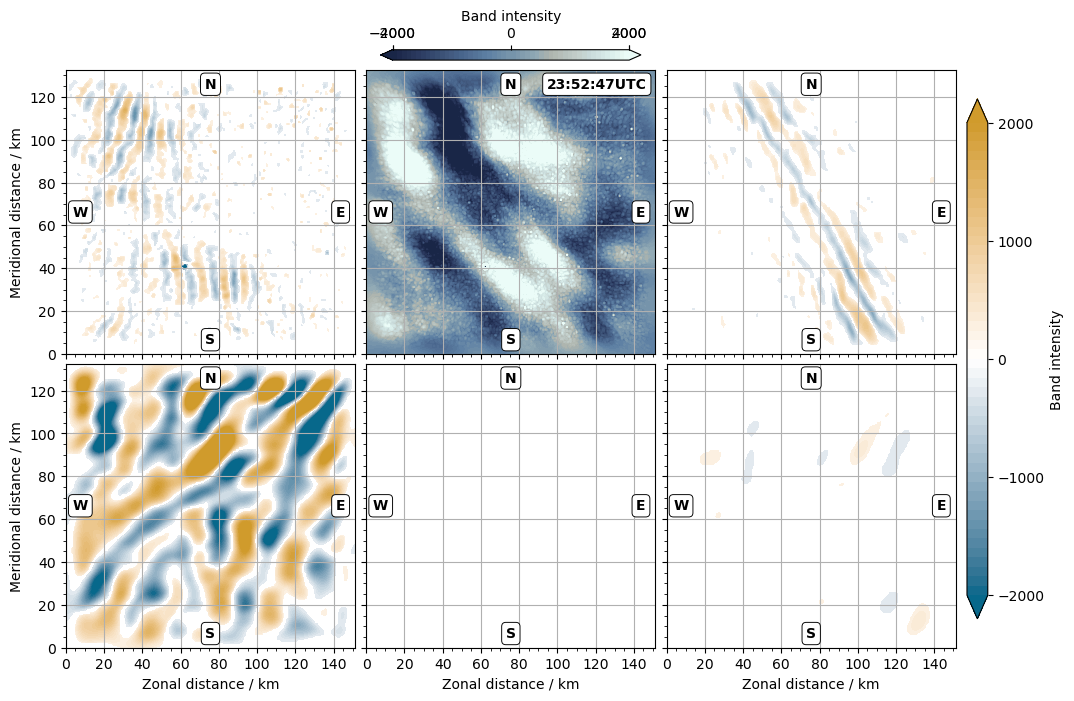

In [12]:
thr = 240
max_abs = 2000
BI_lev0 = np.linspace(-4000,4000,51)
BI_lev0 = np.linspace(-1000,1000,51)
BI_lev = np.linspace(-2000,2000,51)
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1, 1, 1, 0.1], "height_ratios": [0.1, 1, 1]}
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)
royal=get_cmap().reversed()


time_index=135
fig, ax=plt.subplots(3,4, figsize=(12,8), gridspec_kw=gskw,sharex=True, sharey=True)
ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[0,3].axis('off')
ax[1,3].axis('off')
ax[2,3].axis('off')

residual = new_data[:,:,time_index]-ds_small['__xarray_dataarray_variable__'].values[:,:,time_index].T-ds_boom['__xarray_dataarray_variable__'].values[:,:,time_index].T-ds_medium['__xarray_dataarray_variable__'].values[:,:,time_index].T-ds_large['__xarray_dataarray_variable__'].values[:,:,time_index].T-ds_fast['__xarray_dataarray_variable__'].values[:,:,time_index].T

#original = ax[1,1].contourf(x,y,new_data[:,:,time_index],levels=BI_lev0,cmap=nlc,extend='both')
original = ax[1,1].contourf(x,y,residual,levels=BI_lev0,cmap=nlc,extend='both')
cbar = fig.colorbar(original, ax=ax[0,1], location='top', ticks=[-4000,-2000,0,2000,4000], fraction=1, shrink=0.9, extend='both',label='Band intensity', aspect=25)

masked = np.ma.masked_inside(ds_small['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
wave = ax[1,0].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')
cbar = fig.colorbar(wave, ax=ax[1:,3], location='right', ticks=[-2000,-1000,0,1000,2000], fraction=1, shrink=0.9, extend='both',label='Band intensity', aspect=25)

masked = np.ma.masked_inside(ds_boom['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
ax[1,2].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')

masked = np.ma.masked_inside(ds_medium['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
ax[2,0].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')

masked = np.ma.masked_inside(ds_large['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
ax[2,1].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')

masked = np.ma.masked_inside(ds_fast['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
ax[2,2].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')

yl = ['Meridional distance / km','','','Meridional distance / km','','']
xl = ['','','','Zonal distance / km','Zonal distance / km','Zonal distance / km']

for i in range(1,3):
    for j in range(3):
        ax[i,j].set_ylabel(yl[3*(i-1)+j])
        ax[i,j].set_xlabel(xl[3*(i-1)+j])
        ax[i,j].yaxis.set_major_locator(MultipleLocator(20))
        ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())
        ax[i,j].xaxis.set_major_locator(MultipleLocator(20))
        ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())
        ax[i,j].tick_params(which='both', labelbottom=True, labeltop=False)
        ax[i,j].grid()
        ax[i,j].text(0.5, 0.95, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.5, 0.05, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.05, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax[i,j].text(0.95, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

ax[1,1].text(0.97, 0.95, str(BI['time'].isel(time=time_index).values)[11:19]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[1,1].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

ax[1,0].tick_params(labelbottom=False)
ax[1,1].tick_params(labelbottom=False)
ax[1,2].tick_params(labelbottom=False)

In [120]:
thr = 240
max_abs = 2000
BI_lev0 = np.linspace(-4000,4000,51)
BI_lev = np.linspace(-2000,2000,51)
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1, 1, 1, 0.1], "height_ratios": [0.1, 1, 1]}
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)
royal=get_cmap().reversed()


for time_index in range(150):
    fig, ax=plt.subplots(3,4, figsize=(12,8), gridspec_kw=gskw,sharex=True, sharey=True)
    ax[0,0].axis('off')
    ax[0,1].axis('off')
    ax[0,2].axis('off')
    ax[0,3].axis('off')
    ax[1,3].axis('off')
    ax[2,3].axis('off')

    original = ax[1,1].contourf(x,y,new_data[:,:,time_index],levels=BI_lev0,cmap=nlc,extend='both')
    cbar = fig.colorbar(original, ax=ax[0,1], location='top', ticks=[-4000,-2000,0,2000,4000], fraction=1, shrink=0.9, extend='both',label='Band intensity', aspect=25)
    
    masked = np.ma.masked_inside(ds_small['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
    wave = ax[1,0].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')
    cbar = fig.colorbar(wave, ax=ax[1:,3], location='right', ticks=[-2000,-1000,0,1000,2000], fraction=1, shrink=0.9, extend='both',label='Band intensity', aspect=25)
    
    masked = np.ma.masked_inside(ds_boom['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
    ax[1,2].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')
    
    masked = np.ma.masked_inside(ds_medium['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
    ax[2,0].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')
    
    masked = np.ma.masked_inside(ds_large['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
    ax[2,1].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')
    
    masked = np.ma.masked_inside(ds_fast['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
    ax[2,2].contourf(x,y,masked,levels=BI_lev,cmap=royal,norm=norm,extend='both')
    
    yl = ['Meridional distance / km','','','Meridional distance / km','','']
    xl = ['','','','Zonal distance / km','Zonal distance / km','Zonal distance / km']
    
    for i in range(1,3):
        for j in range(3):
            ax[i,j].set_ylabel(yl[3*(i-1)+j])
            ax[i,j].set_xlabel(xl[3*(i-1)+j])
            ax[i,j].yaxis.set_major_locator(MultipleLocator(20))
            ax[i,j].yaxis.set_minor_locator(AutoMinorLocator())
            ax[i,j].xaxis.set_major_locator(MultipleLocator(20))
            ax[i,j].xaxis.set_minor_locator(AutoMinorLocator())
            ax[i,j].tick_params(which='both', labelbottom=True, labeltop=False)
            ax[i,j].grid()
            ax[i,j].text(0.5, 0.95, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                            weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
            ax[i,j].text(0.5, 0.05, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                            weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
            ax[i,j].text(0.05, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                            weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
            ax[i,j].text(0.95, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                            weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    
    ax[1,1].text(0.97, 0.95, str(BI['time'].isel(time=time_index).values)[11:19]+'UTC', verticalalignment='center', horizontalalignment='right', transform=ax[1,1].transAxes, 
                                        weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    
    ax[1,0].tick_params(labelbottom=False)
    ax[1,1].tick_params(labelbottom=False)
    ax[1,2].tick_params(labelbottom=False)

    plt.savefig('./superposition/gary_'+str(time_index).zfill(3)+'.png', dpi=120, facecolor="w", edgecolor="w")#, bbox_inches="tight")
    plt.close()

In [77]:
thr = 240
max_abs = 2000
BI_lev = np.linspace(-6000,6000,51)
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3
gskw = {"hspace": 0.1, "wspace": 0.1, "width_ratios": [1, 1], "height_ratios": [1, 1]}
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)
royal=get_cmap().reversed()

for time_index in range(150):
    fig, ax=plt.subplots(2,2, figsize=(10,10), gridspec_kw=gskw)

    ax[0,0].contourf(x,y,new_data[:,:,time_index]-ds_small['__xarray_dataarray_variable__'].values[:,:,time_index].T,levels=BI_lev,cmap=nlc,extend='both')
    masked = np.ma.masked_inside(ds_small['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
    ax[0,0].contourf(x,y,masked,levels=100,cmap=royal,norm=norm,alpha=0.3,extend='both')
    
    ax[0,1].contourf(x,y,new_data[:,:,time_index]-ds_medium['__xarray_dataarray_variable__'].values[:,:,time_index].T,levels=BI_lev,cmap=nlc,extend='both')
    masked = np.ma.masked_inside(ds_medium['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
    ax[0,1].contourf(x,y,masked,levels=100,cmap=royal,norm=norm,alpha=0.3,extend='both')
    
    ax[1,0].contourf(x,y,new_data[:,:,time_index]-ds_boom['__xarray_dataarray_variable__'].values[:,:,time_index].T,levels=BI_lev,cmap=nlc,extend='both')
    masked = np.ma.masked_inside(ds_boom['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
    ax[1,0].contourf(x,y,masked,levels=100,cmap=royal,norm=norm,alpha=0.3,extend='both')
    
    ax[1,1].contourf(x,y,new_data[:,:,time_index]-ds_large['__xarray_dataarray_variable__'].values[:,:,time_index].T,levels=BI_lev,cmap=nlc,extend='both')
    masked = np.ma.masked_inside(ds_large['__xarray_dataarray_variable__'].values[:,:,time_index].T, -thr, thr)  
    ax[1,1].contourf(x,y,masked,levels=100,cmap=royal,norm=norm,alpha=0.3,extend='both')

    #ax[0].set_title(str(BI['time'].isel(time=t).values)[0:10]+' '+str(BI['time'].isel(time=t).values)[11:19]+'UTC')
    ax[0,0].set_ylabel('Meridional distance / km')
    ax[0,0].set_xlabel('Zonal distance / km')
    ax[0,0].yaxis.set_major_locator(MultipleLocator(20))
    ax[0,0].yaxis.set_minor_locator(AutoMinorLocator())
    ax[0,0].xaxis.set_major_locator(MultipleLocator(20))
    ax[0,0].xaxis.set_minor_locator(AutoMinorLocator())
    ax[0,0].tick_params(which='both', labelbottom=True, labeltop=False)
    #cbar = fig.colorbar(waves, ax=ax[1], location='right', ticks=[-3000,-2000,-1000,0,1000,2000,3000], fraction=1, shrink=0.9, extend='both',label='Band intensity', aspect=25)
    ax[0,0].grid()
    ax[0,0].text(0.5, 0.95, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[0,0].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax[0,0].text(0.5, 0.05, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[0,0].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax[0,0].text(0.05, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[0,0].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax[0,0].text(0.95, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[0,0].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    plt.savefig('./superposition/gary_'+str(time_index).zfill(3)+'.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")
    plt.close()

In [32]:
# Cluster 3
BI_lev = np.linspace(-3000,3000,51)
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3
gskw = {"hspace": 0.04, "width_ratios": [12, 1]}

for t in range(150):
    fig, ax=plt.subplots(1,2, figsize=(nx*0.03+1,ny*0.03), gridspec_kw=gskw)
    ax[1].axis('off')

    plot_field = ax[0].contourf(x,y,new_data[:,:,t],levels=BI_lev,extend='both',cmap=nlc)
    ax[0].set_title(str(BI['time'].isel(time=t).values)[0:10]+' '+str(BI['time'].isel(time=t).values)[11:19]+'UTC')
    ax[0].set_ylabel('Meridional distance / km')
    ax[0].set_xlabel('Zonal distance / km')
    ax[0].yaxis.set_major_locator(MultipleLocator(20))
    ax[0].yaxis.set_minor_locator(AutoMinorLocator())
    ax[0].xaxis.set_major_locator(MultipleLocator(20))
    ax[0].xaxis.set_minor_locator(AutoMinorLocator())
    ax[0].tick_params(which='both', labelbottom=True, labeltop=False)
    cbar = fig.colorbar(waves, ax=ax[1], location='right', ticks=[-3000,-2000,-1000,0,1000,2000,3000], fraction=1, shrink=0.9, extend='both',label='Band intensity', aspect=25)
    ax[0].grid()
    ax[0].text(0.5, 0.95, 'N', verticalalignment='center', horizontalalignment='center', transform=ax[0].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax[0].text(0.5, 0.05, 'S', verticalalignment='center', horizontalalignment='center', transform=ax[0].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax[0].text(0.05, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax[0].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax[0].text(0.95, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax[0].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    #ax.contourf(x,y,recon[:,:,t],levels=gary_lev,extend='both',cmap='RdBu_r',alpha=0.5)
    plt.savefig('./first_separated_wave/gary_'+str(t).zfill(3)+'.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")
    plt.close()

/scratch-local/slurm-job-tmp-9531602/ipykernel_331/405705862.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 829x639 with 3 Axes> than <Figure size 829x639 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(waves, ax=ax[1], location='right', ticks=[-3000,-2000,-1000,0,1000,2000,3000], fraction=1, shrink=0.9, extend='both',label='Band intensity', aspect=25)


In [121]:
import os
import moviepy.video.io.ImageSequenceClip

image_folder = './superposition/'
fps = 15

image_files = [
    os.path.join(image_folder, img)
    for img in os.listdir(image_folder)
    if img.endswith(".png")
]
image_files.sort()
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(image_files, fps=fps)
clip.write_videofile("superposition.mp4")

Moviepy - Building video superposition.mp4.
Moviepy - Writing video superposition.mp4



Moviepy - Done !
Moviepy - video ready superposition.mp4


<xarray.DataArray 'time' ()> Size: 8B
array('2018-05-16T23:32:40.002000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2018-05-16T23:32:40.002000


Text(0, 0.5, 'scale')

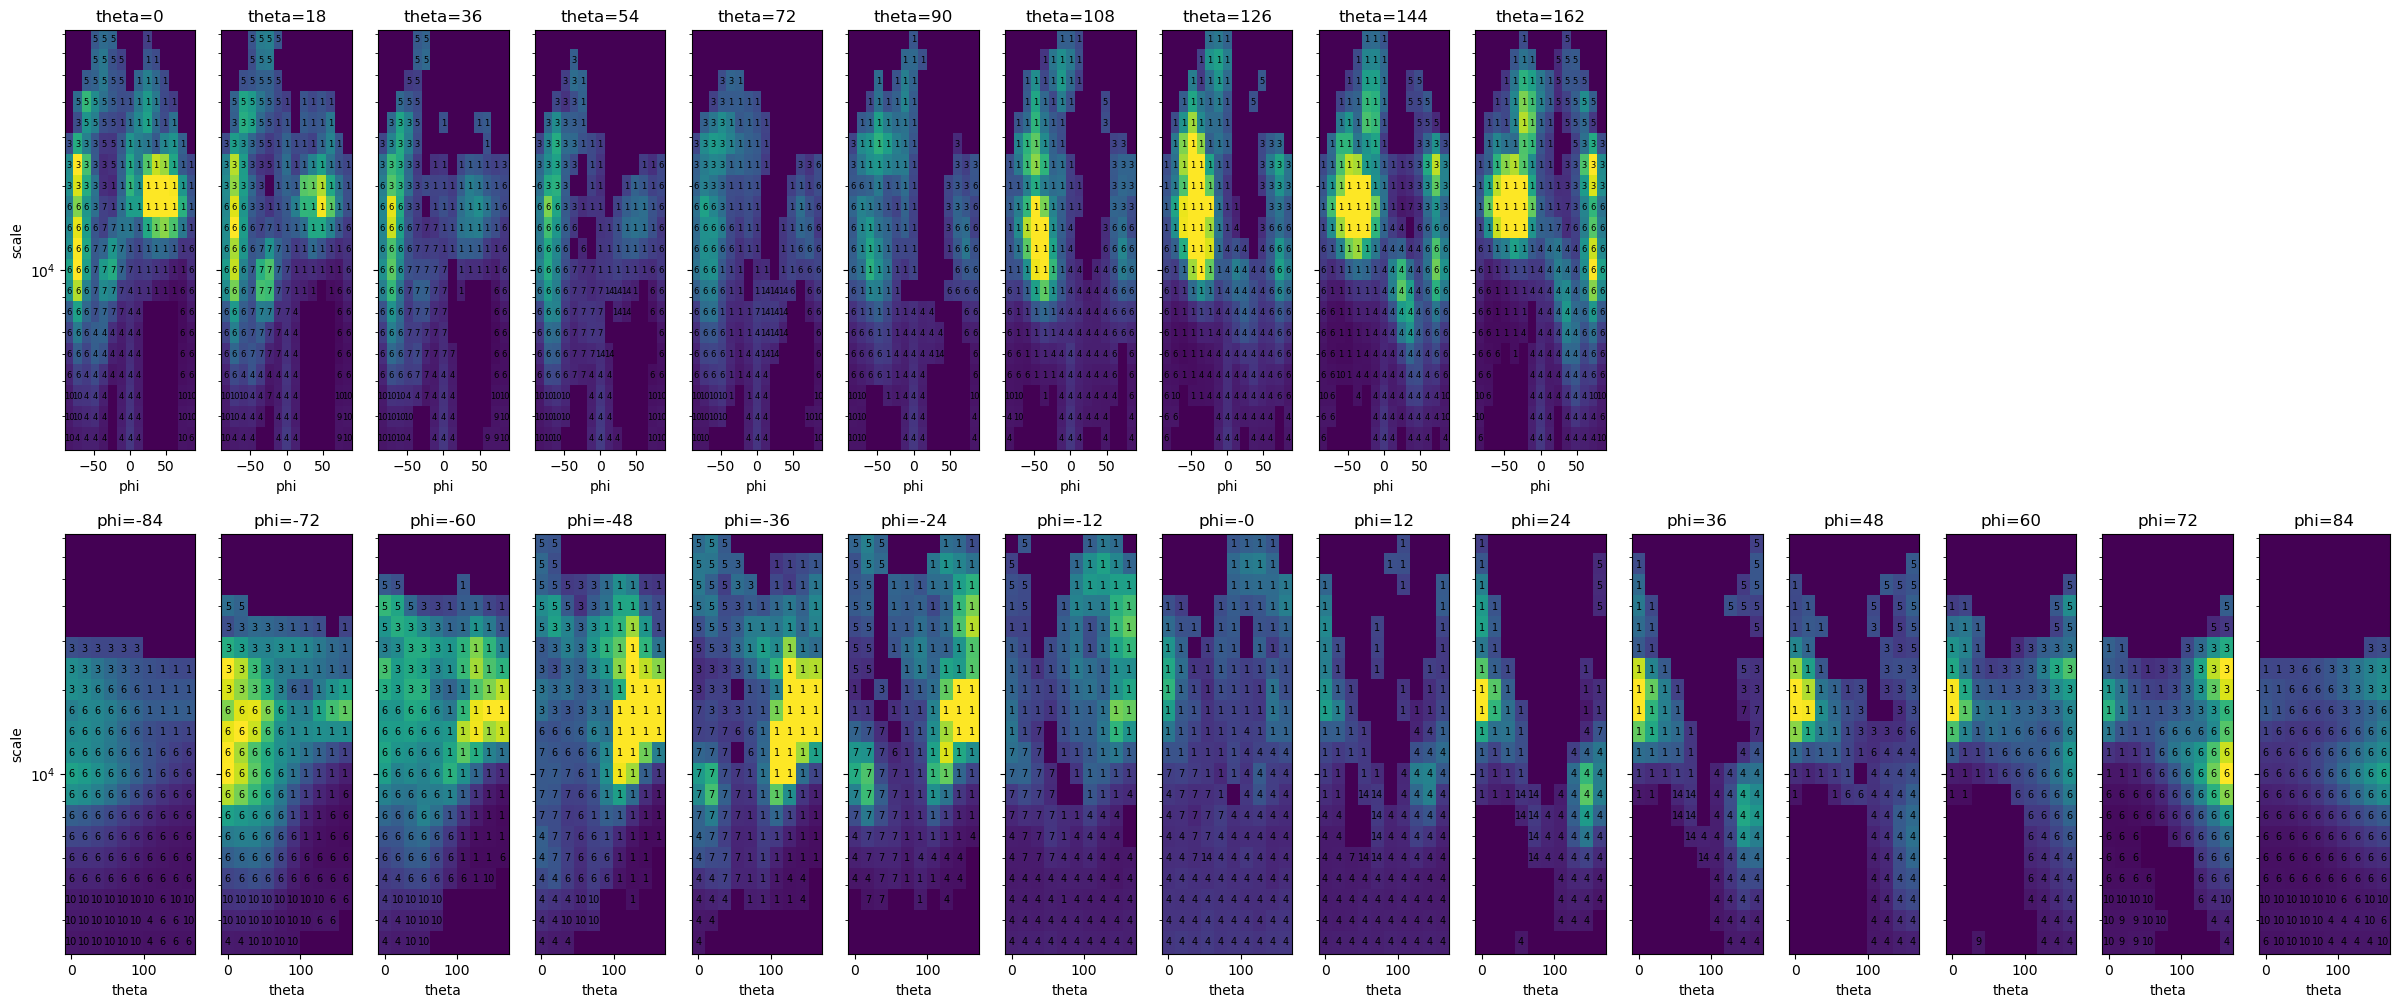

In [135]:
time_index=100
print(BI['time'].isel(time=time_index))

spec_lev = np.linspace(0, 300, 31)
gskw = {
    "hspace": 0.2, "wspace": 0.2,
    "width_ratios": [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    "height_ratios": [1, 1]
}

x=np.rad2deg(cwt_result['phi'])
y=cwt_result['scale']

fig, ax = plt.subplots(2, 15, figsize=(15*2, 6*2), gridspec_kw=gskw, sharey=True)
ax[0,10].axis('off')
ax[0,11].axis('off')
ax[0,12].axis('off')
ax[0,13].axis('off')
ax[0,14].axis('off')

# --- top row ---
for i in range(len(cwt_result['theta'])):
    pcm = ax[0, i].pcolormesh(x,y,result[:, i, :, time_index],vmin=spec_lev.min(), vmax=spec_lev.max(), shading="auto")
    ax[0, i].set_title(f"theta={np.rad2deg(cwt_result['theta'][i]):.0f}")
    ax[0, i].set_yscale('log')
    ax[0, i].set_xlabel('phi')

    for k,xi in enumerate(x):
        for l,yi in enumerate(y):
            if seg[l,i,k, time_index]==0:
                continue
            ax[0,i].text(xi,yi,str(seg[l,i,k, time_index]),horizontalalignment='center',verticalalignment='center',fontsize=6)

ax[0,0].set_ylabel('scale')


x=np.rad2deg(cwt_result['theta'])

# --- bottom row ---
for i in range(len(cwt_result['phi'])):
    pcm = ax[1, i].pcolormesh(x,y,result[:, :, i, time_index], vmin=spec_lev.min(), vmax=spec_lev.max(),shading="auto")
    ax[1, i].set_title(f"phi={np.rad2deg(cwt_result['phi'][i]):.0f}")
    ax[1, i].set_yscale('log')
    ax[1, i].set_xlabel('theta')

    for k,xi in enumerate(x):
        for l,yi in enumerate(y):
            if seg[l,k,i, time_index]==0:
                continue
            ax[1,i].text(xi,yi,str(seg[l,k,i, time_index]),horizontalalignment='center',verticalalignment='center',fontsize=7)

ax[1,0].set_ylabel('scale')

#plt.savefig('ANGWIN_3d_spectrum.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

In [91]:
for s in range(1,np.max(seg)+1):
    mask = (seg == s)
    idxs = np.argwhere(mask)  
    seg_sum=0
    for i, j, k, l in idxs:
        seg_sum+=result[i,j,k,l]#np.abs(cwt_result['decomposition'][i][j][k])#.fill(0)     # fastest; modifies the existing array
    #print(f"{'Summe':10s}: {seg_sum:.1f}")
    print(f"{'Summe:':<10}{np.log(seg_sum):>10}")

Summe:    16.333079723811554
Summe:    14.712165823264808
Summe:    14.533250861693174
Summe:    14.45337844863144
Summe:    14.2964395143065
Summe:    14.154038197875447
Summe:    13.501647153223313
Summe:    13.316851661783238
Summe:    13.22778316197823
Summe:    12.849359542801992
Summe:    12.26470575356793
Summe:    11.698292574692502
Summe:    10.7096064475758
Summe:    10.319272022929008
Summe:    9.444169367132712
Summe:    8.262460673169352
Summe:    7.761734835628884


In [141]:
CWT_filt = copy.deepcopy(cwt_result)

# 1) Build your condition on B (example: zero where B < 0.1)
#mask = (seg == 3) | (seg == 4) | (seg == 9) | (seg == 13) | (seg == 14) | (seg == 15) | (seg == 17)
#mask = (seg == 1) | (seg == 2) | (seg == 6)
#mask = (seg != 5)
mask = (seg == 4) | (seg == 7) | (seg == 12) | (seg == 11) | (seg == 13)

# 2) Get only the indices to touch
idxs = np.argwhere(~mask)  # shape (n_true, 3)

# 3) Zero each selected 3D block in place (no extra allocations)
for i, j, k, l in idxs:
    if CWT_filt['decomposition'][i][j][k] is None:
        continue
    else:
        CWT_filt['decomposition'][i][j][k][:,:,l].fill(0)     # fastest; modifies the existing array

recon_small = parallel.reconstruct3d_parallel(CWT_filt)

100%|██████████| 20/20 [04:18<00:00, 12.91s/it]


In [152]:
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3
df = xr.DataArray(recon_small, coords=[('x', x), ('y', y), ('time', np.linspace(0,nt-1,nt))])
df.to_netcdf('recon_small.nc')

In [145]:
np.percentile(np.abs(recon_small),[50,90,95,99])

array([ 83.95106051, 326.97698448, 480.62852754, 964.83374971])

In [163]:
#from matplotlib.colors import TwoSlopeNorm
#royal = get_cmap()

rec = recon_interesting

thr = 240
masked = np.ma.masked_inside(rec, -thr, thr)  # hides (-thr, +thr)
max_abs = 2000#np.nanmax(np.abs(rec))
norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)
cmap = get_cmap().copy().reversed()
cmap.set_bad(alpha=0)

# Cluster 2
#gary_lev = [-1280,-640,-320,-160,-80,-40,-20,-10,10,20,40,80,160,320,640,1280]
#gary_lev = [-1280,-980,-640,-480,-320,-240,-160,-120,-80,80,120,160,240,320,480,640,980,1280]
x=np.linspace(0,(nx-1)*dx,nx)*1e-3
y=np.linspace(0,(ny-1)*dy,ny)*1e-3
for t in range(rec.shape[2]):
    fig=plt.figure()
    ax = fig.add_subplot()
    #ax.contourf(x,y,recon_large[:,:,t].T,levels=gary_lev,extend='both',cmap='RdBu_r')
    ax.contourf(x,y,masked[:,:,t].T, levels=100, cmap=cmap, norm=norm)
    ax.set_title(str(BI['time'].isel(time=t).values)[0:10]+' '+str(BI['time'].isel(time=t).values)[11:19]+'UTC')
    ax.set_ylabel('Meridional distance / km')
    ax.set_xlabel('Zonal distance / km')
    ax.yaxis.set_major_locator(MultipleLocator(20))
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.xaxis.set_major_locator(MultipleLocator(20))
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', labelbottom=True, labeltop=False)
    ax.grid()
    ax.text(0.5, 0.95, 'N', verticalalignment='center', horizontalalignment='center', transform=ax.transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax.text(0.5, 0.05, 'S', verticalalignment='center', horizontalalignment='center', transform=ax.transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax.text(0.05, 0.5, 'W', verticalalignment='center', horizontalalignment='center', transform=ax.transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax.text(0.95, 0.5, 'E', verticalalignment='center', horizontalalignment='center', transform=ax.transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    plt.savefig('./recon_interesting/gary_'+str(t).zfill(3)+'.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")
    plt.close()

In [164]:
import os
import moviepy.video.io.ImageSequenceClip

image_folder = './recon_interesting/'
fps = 15

image_files = [
    os.path.join(image_folder, img)
    for img in os.listdir(image_folder)
    if img.endswith(".png")
]
image_files.sort()
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(image_files, fps=fps)
clip.write_videofile("recon_interesting.mp4")

Moviepy - Building video recon_interesting.mp4.
Moviepy - Writing video recon_interesting.mp4



Moviepy - Done !
Moviepy - video ready recon_interesting.mp4
